# Factorized Graded Response Model — PROMIS Neuropathic Pain

Fits a **FactorizedGRModel** to multiple pain-related PROMIS banks
from the Neuropathic Pain adult dataset (doi:10.7910/DVN/TJ9MNM).

Only domains with ≥10 items are retained. The SAS data file is
read via pandas.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

## 1. Load Data (Multiple Domains)

In [2]:
from bayesianquilts.data.promis_neuropathic_pain import (
    get_multidomain_data, item_keys, response_cardinality, DOMAINS,
)

df, num_people, scale_indices = get_multidomain_data(
    polars_out=True, min_items=10,
)

print(f"\nDataset: {num_people} people, {len(item_keys)} total items, "
      f"{len(scale_indices)} domains")
print(f"Response categories: {response_cardinality} (0-{response_cardinality - 1})")
for domain, indices in scale_indices.items():
    print(f"  {domain}: {len(indices)} items")
df.head()

Auto-selected 3 domains with ≥10 items: ['pain_interference', 'pain_behavior', 'global_health']
  pain_interference: 36 items (indices 0-35)
  pain_behavior: 37 items (indices 36-72)
  global_health: 10 items (indices 73-82)
Total: 83 items across 3 domains

Dataset: 963 people, 83 total items, 3 domains
Response categories: 5 (0-4)
  pain_interference: 36 items
  pain_behavior: 37 items
  global_health: 10 items


person,PAININ1,PAININ10,PAININ11,PAININ12,PAININ13,PAININ14,PAININ16,PAININ17,PAININ19,PAININ20,PAININ22,PAININ24,PAININ26,PAININ29,PAININ3,PAININ31,PAININ32,PAININ34,PAININ35,PAININ36,PAININ37,PAININ38,PAININ39,PAININ46,PAININ48,PAININ49,PAININ5,PAININ50,PAININ51,PAININ53,PAININ54,PAININ55,PAININ56,PAININ6,PAININ8,PAININ9,…,PAINBE25,PAINBE26,PAINBE27,PAINBE28,PAINBE29,PAINBE3,PAINBE31,PAINBE32,PAINBE33,PAINBE35,PAINBE37,PAINBE38,PAINBE39,PAINBE41,PAINBE42,PAINBE43,PAINBE44,PAINBE45,PAINBE46,PAINBE47,PAINBE48,PAINBE49,PAINBE50,PAINBE51,PAINBE6,PAINBE8,PAINBE9,Global01,Global02,Global03,Global04,Global05,Global06,Global07,Global08,Global09r,Global10
u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,-1.0,-1.0,-1.0,-1.0,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,3.0,-1.0,4.0,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,…,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,2.0,0.0,1.0,0.0,1.0,-1.0,3.0,0.0,2.0
1,-1.0,0.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,…,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,2.0,3.0,2.0,3.0,1.0,3.0,1.0
2,-1.0,4.0,-1.0,-1.0,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,-1.0,4.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,4.0,…,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,-1.0,0.0,1.0,1.0,3.0,3.0,4.0,-1.0,-1.0,-1.0,-1.0
3,-1.0,0.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,…,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,4.0,3.0,3.0,4.0,4.0,3.0,0.0,1.0,4.0,1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,2.0,-1.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,…,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3.0,-1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,2.0,3.0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 963


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 61154
N: 963, Batch size: 256, Steps per epoch: 4


## 3. Fit Baseline FactorizedGRModel (Ignorable Missingness)

Each domain loads onto its own latent dimension. The model estimates
per-domain abilities and item discriminations.

In [5]:
from bayesianquilts.irt.factorizedgrm import FactorizedGRModel

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

model_baseline = FactorizedGRModel(
    scale_indices=scale_indices,
    discrimination_prior_scale=2.0,
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Baseline final loss: {losses_baseline[-1]:.2f}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['discriminations_0\\softplus\\normal\\loc', 'discriminations_0\\softplus\\normal\\scale', 'mu_0\\identity\\normal\\loc', 'mu_0\\identity\\normal\\scale', 'difficulties0_0\\identity\\normal\\loc', 'difficulties0_0\\identity\\normal\\scale', 'ddifficulties_0\\softplus\\normal\\loc', 'ddifficulties_0\\softplus\\normal\\scale', 'abilities_0\\identity\\normal\\loc', 'abilities_0\\identity\\normal\\scale', 'discriminations_1\\softplus\\normal\\loc', 'discriminations_1\\softplus\\normal\\scale', 'mu_1\\identity\\normal\\loc', 'mu_1\\identity\\normal\\scale', 'difficulties0_1\\identity\\normal\\loc', 'difficulties0_1\\identity\\normal\\scale', 'ddifficulties_1\\softplus\\normal\\loc', 'ddifficulties_1\\softplus\\normal\\scale', 'abilities_1\\identity\\normal\\loc', 'abilities_1\\identity\\normal\\scal

Epoch 1/200 (LR: 0.000200):   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/4 [00:08<?, ?batch/s, best_loss=inf, loss=60.7420]

Epoch 1/200 (LR: 0.000200):  25%|██▌       | 1/4 [00:08<00:26,  8.92s/batch, best_loss=inf, loss=60.7420]

Epoch 1/200 (LR: 0.000200):  25%|██▌       | 1/4 [00:09<00:26,  8.92s/batch, best_loss=inf, loss=61.1494]

...

Epoch 30/200 (LR: 0.000000):   0%|          | 0/4 [00:00<?, ?batch/s, best_loss=58.8614, loss=61.0132]

Epoch 30/200 (LR: 0.000000):   0%|          | 0/4 [00:00<?, ?batch/s, best_loss=58.8614, loss=61.3791]

Epoch 30/200 (LR: 0.000000):  75%|███████▌  | 3/4 [00:00<00:00, 28.46batch/s, best_loss=58.8614, loss=61.3791]

Epoch 30/200 (LR: 0.000000):  75%|███████▌  | 3/4 [00:00<00:00, 28.46batch/s, best_loss=58.8614, loss=51.6312]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000000

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
Baseline final loss: 58.87


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit Pairwise Ordinal Stacking Model

In [8]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=12,
    n_jobs=-1,
    seed=42,
)

Missing values per item:
PAININ1      933
PAININ10     716
PAININ11     963
PAININ12     897
PAININ13     880
            ... 
Global06       0
Global07     414
Global08       3
Global09r     10
Global10       5
Length: 83, dtype: int64
Computing feature correlations...
Fitting PairwiseOrdinalStackingModel
  Variables: 83
  Observations: 963
  Min obs per model: 5
  Parallel jobs: -1
  Top features per target: 12
  DM alpha prior: 0.5
  Global ordinal values: [0. 1. 2. 3. 4.] (n=5)

Fitting marginal regression models...
  83 of 83 remaining


/home/josh/workspace/bayesianquilts/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Var 1 (PAININ10): elpd/n=-1.4896


  Var 3 (PAININ12): elpd/n=-0.8256
  Var 5 (PAININ14): elpd/n=-1.6005
  Var 8 (PAININ19): elpd/n=-0.5374


  Var 10 (PAININ22): elpd/n=-0.9871
  Var 12 (PAININ26): elpd/n=-1.5636
  Var 14 (PAININ3): elpd/n=-1.4898
  Var 15 (PAININ31): elpd/n=-1.0044
  Var 16 (PAININ32): elpd/n=11.3833


...

  DM (Global03->PAINBE8): elpd/n=-1.3429, n=816
  DM (Global04->PAINBE8): elpd/n=-1.3864, n=810
  DM (Global05->PAINBE8): elpd/n=-1.3577, n=815
  DM (Global06->PAINBE8): elpd/n=-1.2596, n=817
  DM (Global07->PAINBE8): elpd/n=-1.2769, n=515
  DM (Global08->PAINBE8): elpd/n=-1.3039, n=814
  DM (Global09r->PAINBE8): elpd/n=-1.2891, n=807
  DM (Global10->PAINBE8): elpd/n=-1.3746, n=814
  DM (PAININ1->Global01): elpd/n=-1.1553, n=30
  DM (PAININ10->Global01): elpd/n=-1.3716, n=247
  DM (PAININ12->Global01): elpd/n=-1.3795, n=66
  DM (PAININ13->Global01): elpd/n=-1.4439, n=83
  DM (PAININ14->Global01): elpd/n=-1.2644, n=152
  DM (PAININ17->Global01): elpd/n=-1.4053, n=30
  DM (PAININ19->Global01): elpd/n=-1.5621, n=16
  DM (PAININ20->Global01): elpd/n=-1.4468, n=45
  DM (PAININ22->Global01): elpd/n=-1.2689, n=809
  DM (PAININ24->Global01): elpd/n=-1.5181, n=63
  DM (PAININ26->Global01): elpd/n=-1.3208, n=238
  DM (PAININ29->Global01): elpd/n=-0.7895, n=14
  DM (PAININ3->Global01): elpd/n=-1.

  DM (PAININ10->Global03): elpd/n=-1.3513, n=247
  DM (PAININ12->Global03): elpd/n=-1.2407, n=66
  DM (PAININ13->Global03): elpd/n=-1.2906, n=82
  DM (PAININ14->Global03): elpd/n=-1.2473, n=152
  DM (PAININ17->Global03): elpd/n=-1.4011, n=30
  DM (PAININ19->Global03): elpd/n=-1.3495, n=16
  DM (PAININ20->Global03): elpd/n=-1.3631, n=45
  DM (PAININ22->Global03): elpd/n=-1.2556, n=808
  DM (PAININ24->Global03): elpd/n=-1.4683, n=63
  DM (PAININ26->Global03): elpd/n=-1.2558, n=237
  DM (PAININ29->Global03): elpd/n=-0.9065, n=14
  DM (PAININ3->Global03): elpd/n=-1.3442, n=228
  DM (PAININ31->Global03): elpd/n=-1.2598, n=808
  DM (PAININ34->Global03): elpd/n=-1.2666, n=808
  DM (PAININ36->Global03): elpd/n=-1.2242, n=608
  DM (PAININ39->Global03): elpd/n=-1.4227, n=40
  DM (PAININ49->Global03): elpd/n=-1.1084, n=6
  DM (PAININ50->Global03): elpd/n=-0.6835, n=5
  DM (PAININ51->Global03): elpd/n=-1.0176, n=10
  DM (PAININ56->Global03): elpd/n=-1.3844, n=42
  DM (PAININ8->Global03): elpd/n=-1

  DM (Global04->Global05): elpd/n=-1.1802, n=951
  DM (Global06->Global05): elpd/n=-1.3857, n=958
  DM (Global07->Global05): elpd/n=-1.4332, n=546
  DM (Global08->Global05): elpd/n=-1.4184, n=956
  DM (Global09r->Global05): elpd/n=-1.1873, n=948
  DM (Global10->Global05): elpd/n=-1.3717, n=953
  DM (PAININ1->Global06): elpd/n=-1.3334, n=30
  DM (PAININ10->Global06): elpd/n=-1.1841, n=247
  DM (PAININ12->Global06): elpd/n=-0.9800, n=66
  DM (PAININ13->Global06): elpd/n=-1.3601, n=83
  DM (PAININ14->Global06): elpd/n=-1.3356, n=152
  DM (PAININ17->Global06): elpd/n=-1.4500, n=30
  DM (PAININ19->Global06): elpd/n=-0.8685, n=16
  DM (PAININ20->Global06): elpd/n=-0.6775, n=45
  DM (PAININ22->Global06): elpd/n=-1.2453, n=810
  DM (PAININ24->Global06): elpd/n=-0.8399, n=63
  DM (PAININ26->Global06): elpd/n=-1.3247, n=238
  DM (PAININ29->Global06): elpd/n=-1.4262, n=14
  DM (PAININ3->Global06): elpd/n=-1.2138, n=228
  DM (PAININ31->Global06): elpd/n=-1.2587, n=810
  DM (PAININ34->Global06): el

  DM (PAININ39->Global08): elpd/n=-1.2210, n=40
  DM (PAININ49->Global08): elpd/n=-1.1084, n=6
  DM (PAININ50->Global08): elpd/n=-1.2745, n=5
  DM (PAININ51->Global08): elpd/n=-1.0176, n=10
  DM (PAININ56->Global08): elpd/n=-1.2182, n=42
  DM (PAININ8->Global08): elpd/n=-1.2283, n=152
  DM (PAININ9->Global08): elpd/n=-1.1881, n=959
  DM (PAINBE11->Global08): elpd/n=-1.4545, n=17
  DM (PAINBE16->Global08): elpd/n=-1.2429, n=617
  DM (PAINBE17->Global08): elpd/n=-1.2972, n=42
  DM (PAINBE2->Global08): elpd/n=-1.2256, n=418
  DM (PAINBE21->Global08): elpd/n=-1.2702, n=420
  DM (PAINBE24->Global08): elpd/n=-1.2308, n=141
  DM (PAINBE25->Global08): elpd/n=-1.3335, n=147
  DM (PAINBE26->Global08): elpd/n=-1.1720, n=360
  DM (PAINBE27->Global08): elpd/n=-1.1796, n=511
  DM (PAINBE3->Global08): elpd/n=-1.1873, n=139
  DM (PAINBE31->Global08): elpd/n=-1.7156, n=10
  DM (PAINBE33->Global08): elpd/n=-1.2139, n=122
  DM (PAINBE37->Global08): elpd/n=-1.2782, n=160
  DM (PAINBE45->Global08): elpd/n=

  DM (PAINBE17->Global10): elpd/n=-1.3955, n=42
  DM (PAINBE2->Global10): elpd/n=-1.2814, n=417
  DM (PAINBE21->Global10): elpd/n=-1.3390, n=420
  DM (PAINBE24->Global10): elpd/n=-1.4949, n=141
  DM (PAINBE25->Global10): elpd/n=-1.5164, n=147
  DM (PAINBE26->Global10): elpd/n=-1.3880, n=358
  DM (PAINBE27->Global10): elpd/n=-1.3638, n=510
  DM (PAINBE3->Global10): elpd/n=-1.4318, n=139
  DM (PAINBE31->Global10): elpd/n=-1.3443, n=10
  DM (PAINBE33->Global10): elpd/n=-1.2576, n=121
  DM (PAINBE37->Global10): elpd/n=-1.3931, n=160
  DM (PAINBE45->Global10): elpd/n=-1.5054, n=146
  DM (PAINBE8->Global10): elpd/n=-1.4102, n=814
  DM (Global01->Global10): elpd/n=-1.4286, n=957
  DM (Global02->Global10): elpd/n=-1.3634, n=905
  DM (Global03->Global10): elpd/n=-1.4170, n=956
  DM (Global04->Global10): elpd/n=-1.2118, n=951
  DM (Global05->Global10): elpd/n=-1.3186, n=953
  DM (Global06->Global10): elpd/n=-1.4171, n=958
  DM (Global07->Global10): elpd/n=-1.3480, n=547
  DM (Global08->Global10)

In [9]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 52 targets


## 4b. Fit Pairwise-Only Factorized GRM

Uses only the pairwise ordinal stacking ensemble (w=1 for all items).

In [10]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)
print(pairwise_imputation.summary())

model_pairwise = FactorizedGRModel(
    scale_indices=scale_indices,
    discrimination_prior_scale=2.0,
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Pairwise-Only Imputation (w_mice = 1.0 for all items):
  Variables: 83
  Univariate models: 541


Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['discriminations_0\\softplus\\normal\\loc', 'discriminations_0\\softplus\\normal\\scale', 'mu_0\\identity\\normal\\loc', 'mu_0\\identity\\normal\\scale', 'difficulties0_0\\identity\\normal\\loc', 'difficulties0_0\\identity\\normal\\scale', 'ddifficulties_0\\softplus\\normal\\loc', 'ddifficulties_0\\softplus\\normal\\scale', 'abilities_0\\identity\\normal\\loc', 'abilities_0\\identity\\normal\\scale', 'discriminations_1\\softplus\\normal\\loc', 'discriminations_1\\softplus\\normal\\scale', 'mu_1\\identity\\normal\\loc', 'mu_1\\identity\\normal\\scale', 'difficulties0_1\\identity\\normal\\loc', 'difficulties0_1\\identity\\normal\\scale', 'ddifficulties_1\\softplus\\normal\\loc', 'ddifficulties_1\\softplus\\normal\\scale', 'abilities_1\\identity\\norma

Epoch 1/200 (LR: 0.000200):   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/4 [00:13<?, ?batch/s, best_loss=inf, loss=171.1123]

Epoch 1/200 (LR: 0.000200):  25%|██▌       | 1/4 [00:13<00:40, 13.51s/batch, best_loss=inf, loss=171.1123]

...

Epoch 24/200 (LR: 0.000000):  75%|███████▌  | 3/4 [00:14<00:04,  4.81s/batch, best_loss=151.7754, loss=170.0822]

Epoch 24/200 (LR: 0.000000):  75%|███████▌  | 3/4 [00:18<00:04,  4.81s/batch, best_loss=151.7754, loss=133.5992]

Epoch 24/200 (LR: 0.000000): 100%|██████████| 4/4 [00:18<00:00,  4.37s/batch, best_loss=151.7754, loss=133.5992]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000000

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---


Final pairwise loss: 161.13


In [11]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 83 items, 963 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
PAININ1         0.814    -1.0367    -1.9487     0.000
PAININ10        0.614    -1.0728    -1.1869     0.000
PAININ11        0.000       -inf       -inf       inf
PAININ12        0.725    -0.6802    -0.7842     0.000
PAININ13        0.173    -1.8510    -1.4755     0.000
PAININ14        0.902    -1.2331    -2.0222     0.000
PAININ16        0.000       -inf       -inf       inf
PAININ17        0.000   -69.0776    -0.2521     0.000
PAININ19        0.924    -0.5189    -0.6631     0.000
PAININ20        0.529    -1.7382    -0.3512     0.000
PAININ22        1.000    -1.1336    -1.4369     0.000
PAININ24        0.603    -1.7555    -1.2103     0.000
PAININ26        0.973    -1.0876    -1.4078     0.000
PAININ29        0.000    -3.6681    -0.7810     0.000
PAININ3         1.000    -1.0540    -1.4620     0.000
PAININ31        0.937    -1.

## 5. Fit Mixed Factorized GRM (Pairwise + IRT Imputation)

In [12]:
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    n_irt = sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)
    print(f"IRT contributes to {n_irt}/{len(item_keys)} items")
    model_imputed = FactorizedGRModel(
        scale_indices=scale_indices,
        discrimination_prior_scale=2.0,
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        response_cardinality=response_cardinality,
        imputation_model=mixed_imputation,
        dtype=jnp.float64,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        patience=10,
        initial_values=model_pairwise.params,
    )

    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

IRT contributes to 54/83 items


Warm-starting from pairwise model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['discriminations_0\\softplus\\normal\\loc', 'discriminations_0\\softplus\\normal\\scale', 'mu_0\\identity\\normal\\loc', 'mu_0\\identity\\normal\\scale', 'difficulties0_0\\identity\\normal\\loc', 'difficulties0_0\\identity\\normal\\scale', 'ddifficulties_0\\softplus\\normal\\loc', 'ddifficulties_0\\softplus\\normal\\scale', 'abilities_0\\identity\\normal\\loc', 'abilities_0\\identity\\normal\\scale', 'discriminations_1\\softplus\\normal\\loc', 'discriminations_1\\softplus\\normal\\scale', 'mu_1\\identity\\normal\\loc', 'mu_1\\identity\\normal\\scale', 'difficulties0_1\\identity\\normal\\loc', 'difficulties0_1\\identity\\normal\\scale', 'ddifficulties_1\\softplus\\normal\\loc', 'ddifficulties_1\\softplus\\normal\\scale', 'abilities_1\\identity\\norma

Epoch 1/200 (LR: 0.000100):   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000100):   0%|          | 0/4 [00:09<?, ?batch/s, best_loss=inf, loss=2452.9928]

Epoch 1/200 (LR: 0.000100):  25%|██▌       | 1/4 [00:09<00:27,  9.28s/batch, best_loss=inf, loss=2452.9928]

...

Epoch 11/200 (LR: 0.000000):  75%|███████▌  | 3/4 [00:18<00:05,  5.29s/batch, best_loss=2163.5999, loss=2451.7868]

Epoch 11/200 (LR: 0.000000):  75%|███████▌  | 3/4 [00:26<00:05,  5.29s/batch, best_loss=2163.5999, loss=1868.8718]

Epoch 11/200 (LR: 0.000000): 100%|██████████| 4/4 [00:26<00:00,  6.44s/batch, best_loss=2163.5999, loss=1868.8718]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000000

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 2 times during training.


Final mixed loss: 2307.09


In [13]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

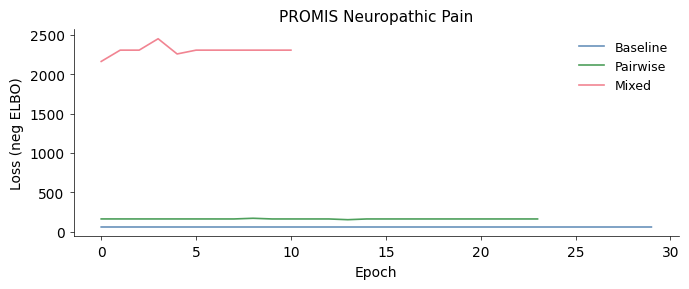

In [14]:
fig = plot_loss_comparison(losses_baseline, losses_imputed,
                          title='PROMIS Neuropathic Pain',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Per-Domain Ability Comparison

Compare ability estimates across domains between baseline and imputed models.

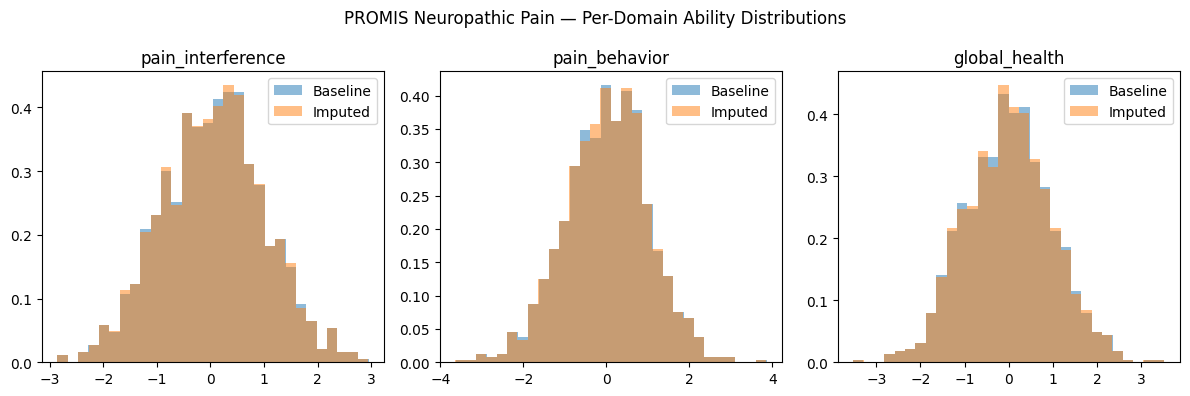

In [16]:
# Plot per-domain ability distributions
fig, axes = plt.subplots(1, len(scale_indices), figsize=(4 * len(scale_indices), 4))
if len(scale_indices) == 1:
    axes = [axes]

for d, (ax, (domain, indices)) in enumerate(zip(axes, scale_indices.items())):
    ab_base = np.array(model_baseline.calibrated_expectations[f'abilities_{d}']).flatten()
    ab_imp = np.array(model_imputed.calibrated_expectations[f'abilities_{d}']).flatten()
    ax.hist(ab_base, bins=30, alpha=0.5, label='Baseline', density=True)
    ax.hist(ab_imp, bins=30, alpha=0.5, label='Imputed', density=True)
    ax.set_title(domain)
    ax.legend()

fig.suptitle('PROMIS Neuropathic Pain — Per-Domain Ability Distributions')
fig.tight_layout()
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Summary

This notebook fitted a Factorized Graded Response Model to multiple
pain-related PROMIS item banks from the Neuropathic Pain adult dataset.

Each domain (Pain Interference, Pain Behavior, etc.) loads onto its own
latent dimension. Only domains with ≥10 items were retained.

Data source: Harvard Dataverse (doi:10.7910/DVN/TJ9MNM).